# Session 16 — Classification Evaluation Metrics: Confusion Matrix, Accuracy, Precision, Recall, and F1-Score
---

### **Overview & Learning Objectives**
In this session, we investigate the mathematical foundations, diagnostic interpretations, and programmatic implementations of **Supervised Classification Evaluation Metrics**. In real-world data science workflows, model accuracy is frequently insufficient—and often dangerous—when evaluating decision systems on imbalanced datasets.

We systematically examine:
1. **The Confusion Matrix**: Deconstruction of classification decisions into **True Positives (TP)**, **True Negatives (TN)**, **False Positives (FP / Type I Error)**, and **False Negatives (FN / Type II Error)**.
2. **First-Principles Metric Derivations**: Manual calculations and algorithmic computations of **Accuracy**, **Precision (Positive Predictive Value)**, **Recall (Sensitivity / True Positive Rate)**, **Specificity (True Negative Rate)**, and the **F1-Score (Harmonic Mean)**.
3. **Reusable Industrial Tooling**: Designing a robust Python function `print_confusion_matrix(tp, tn, fp, fn)` with input validation, readable tabular formatting, and automated derived metrics.
4. **Mission-Critical Domain Applications**:
   - **Spam Filtering**: Avoiding legitimate message loss via precision optimization.
   - **Social Media Fake News Detection**: Balancing viral misinformation containment against wrongful censorship.
   - **Food Delivery & Fintech Fraud Detection**: Reconciling direct financial fraud losses with customer friction at checkout.

| Question | Problem Domain | Positive Class ($+1$) | Given Contingency Counts | Core Objective & Deliverable |
|:---|:---|:---|:---|:---|
| **Question 1** | Email Spam Filtering | **Spam** | $\text{TP}=50, \text{TN}=120, \text{FP}=10, \text{FN}=20$ | Manual step-by-step derivation of Accuracy, Precision, Recall & F1-Score |
| **Question 2** | Generic Diagnostic Function | *Configurable* | Dynamic input $(\text{tp}, \text{tn}, \text{fp}, \text{fn})$ | Reusable `print_confusion_matrix` table formatter & metric summary |
| **Question 3** | Social Media Fake News Detection | **Fake News** | $\text{TP}=60, \text{TN}=120, \text{FP}=10, \text{FN}=30$ | Precision vs. Recall trade-off & content moderation policy analysis |
| **Question 4** | Food Delivery Fraud Detection | **Fraudulent Order** | $\text{TP}=40, \text{TN}=150, \text{FP}=20, \text{FN}=10$ | F1-Score calculation & single-line holistic performance rationale |


---
## Question 1
**Given the following confusion matrix from a spam filter (Actual: Spam=70, Not Spam=130; Predicted: Spam=60, Not Spam=140; TP=50, TN=120, FP=10, FN=20), manually calculate the values of accuracy, precision, recall, and F1 score on paper or in a Jupyter notebook.**

---

### 1. Conceptual Definition & Mathematical Foundation

A **Confusion Matrix** (also called an error contingency matrix) is a $2 \times 2$ grid that cross-classifies the ground truth actual outcomes against a classifier's predicted outcomes:

```
                                  PREDICTED CLASS
                           Predicted Positive (1)   Predicted Negative (0)     Row Total
ACTUAL       Actual          True Positive (TP)       False Negative (FN)     Actual Positives
CLASS      Positive (1)        [Spam -> Spam]          [Spam -> Not Spam]       (TP + FN)
             
             Actual          False Positive (FP)      True Negative (TN)      Actual Negatives
           Negative (0)      [Not Spam -> Spam]      [Not Spam -> Not Spam]     (FP + TN)
           
           Column Total       Predicted Positives     Predicted Negatives        Grand Total
                                   (TP + FP)               (FN + TN)         (TP+TN+FP+FN = N)
```

#### **Given Problem Parameters**:
- **Total Emails Evaluated ($N$)**: $70 + 130 = 200$
- **Positive Class ($+1$)**: **Spam**
- **Negative Class ($0$)**: **Not Spam (Legitimate / Ham)**
- **Actual Class Marginals**:
  - $\text{Actual Spam} = \text{TP} + \text{FN} = 50 + 20 = 70$
  - $\text{Actual Not Spam} = \text{FP} + \text{TN} = 10 + 120 = 130$
- **Predicted Class Marginals**:
  - $\text{Predicted Spam} = \text{TP} + \text{FP} = 50 + 10 = 60$
  - $\text{Predicted Not Spam} = \text{FN} + \text{TN} = 20 + 120 = 140$
- **Four Core Quadrants**:
  - $\mathbf{TP = 50}$: Actual spam emails correctly identified and diverted to the spam folder.
  - $\mathbf{TN = 120}$: Legitimate emails correctly identified and delivered to the inbox.
  - $\mathbf{FP = 10}$ (Type I Error / False Alarm): Legitimate emails mistakenly flagged as spam and hidden from the recipient.
  - $\mathbf{FN = 20}$ (Type II Error / Miss): Spam emails that evaded the filter and landed in the primary inbox.

---

### 2. Step-by-Step Manual Mathematical Derivations

#### **A. Accuracy**
Accuracy is the proportion of total decisions that were objectively correct:
$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}} = \frac{\text{Correct Classifications}}{\text{Total Instances}}$$

$$\text{Accuracy} = \frac{50 + 120}{50 + 120 + 10 + 20} = \frac{170}{200} = \frac{17}{20} = \mathbf{0.8500 \quad (85.00\%)}$$

#### **B. Precision (Positive Predictive Value - PPV)**
Precision quantifies how trustworthy the model is when it predicts an email is spam:
$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} = \frac{\text{True Positives}}{\text{Total Predicted Positives}}$$

$$\text{Precision} = \frac{50}{50 + 10} = \frac{50}{60} = \frac{5}{6} = \mathbf{0.8333... \quad (83.33\%)}$$

#### **C. Recall (Sensitivity / True Positive Rate - TPR)**
Recall measures the model's ability to locate and capture all actual spam emails:
$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} = \frac{\text{True Positives}}{\text{Total Actual Positives}}$$

$$\text{Recall} = \frac{50}{50 + 20} = \frac{50}{70} = \frac{5}{7} = \mathbf{0.714285... \quad (71.43\%)}$$

#### **D. Specificity (True Negative Rate - TNR)**
Specificity measures how effectively the filter leaves legitimate emails undisturbed:
$$\text{Specificity} = \frac{\text{TN}}{\text{TN} + \text{FP}} = \frac{120}{120 + 10} = \frac{120}{130} = \frac{12}{13} = \mathbf{0.923076... \quad (92.31\%)}$$

#### **E. F1-Score (Harmonic Mean of Precision and Recall)**
The arithmetic mean fails when one metric collapses toward zero. The harmonic mean strongly penalizes imbalances between Precision and Recall:
$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Substituting the exact fraction forms $\text{Precision} = \frac{5}{6}$ and $\text{Recall} = \frac{5}{7}$:
$$\text{Numerator} = 2 \times \left(\frac{5}{6} \times \frac{5}{7}\right) = 2 \times \frac{25}{42} = \frac{50}{42}$$
$$\text{Denominator} = \frac{5}{6} + \frac{5}{7} = \frac{35 + 30}{42} = \frac{65}{42}$$
$$\text{F1-Score} = \frac{50 / 42}{65 / 42} = \frac{50}{65} = \frac{10}{13} = \mathbf{0.769230... \quad (76.92\%)}$$

*Cross-Check via Direct Contingency Cell Formulation*:
$$\text{F1-Score} = \frac{2 \cdot \text{TP}}{2 \cdot \text{TP} + \text{FP} + \text{FN}} = \frac{2(50)}{2(50) + 10 + 20} = \frac{100}{100 + 30} = \frac{100}{130} = \frac{10}{13} = \mathbf{0.7692 \quad (76.92\%)}$$


QUESTION 1: SPAM FILTER CONFUSION MATRIX MANUAL CALCULATION VERIFICATION
Given Contingency Cells:
  - True Positives  (TP) : 50   (Spam correctly caught)
  - True Negatives  (TN) : 120  (Not Spam correctly delivered)
  - False Positives (FP) : 10   (Legitimate email misclassified as Spam - Type I Error)
  - False Negatives (FN) : 20   (Spam email missed into inbox - Type II Error)
  - Total Samples   (N)  : 200
------------------------------------------------------------------------------
1. Accuracy   = (TP + TN) / Total        = (50 + 120) / 200 = 170/200 = 17/20 = 0.8500 (85.00%)
2. Precision  = TP / (TP + FP)           = 50 / (50 + 10) = 50/60 = 5/6 = 0.8333 (83.33%)
3. Recall     = TP / (TP + FN)           = 50 / (50 + 20) = 50/70 = 5/7 = 0.7143 (71.43%)
4. F1-Score   = 2*(P*R) / (P + R)        = 2*(5/6 * 5/7) / (5/6 + 5/7) = 10/13 = 0.7692 (76.92%)

SCIKIT-LEARN PROGRAMMATIC VALIDATION:
  - sklearn accuracy_score  : 0.8500
  - sklearn precision_score : 0.8333
  - sklearn recall_s

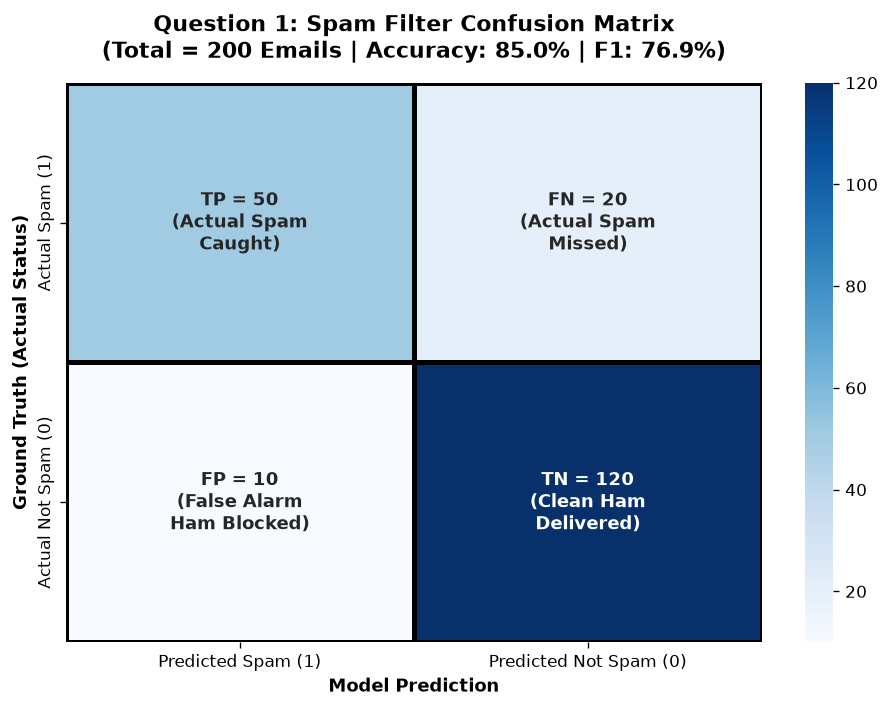

In [1]:
# ==============================================================================
# QUESTION 1: VERIFICATION & VISUALIZATION IN PYTHON
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
mpl.rcParams['font.enable_last_resort'] = False
mpl.rcParams['font.family'] = 'DejaVu Sans'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fractions import Fraction
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Given contingency counts
tp = 50
tn = 120
fp = 10
fn = 20

# 2. Step-by-step arithmetic using exact Fractions
total = tp + tn + fp + fn
acc_frac = Fraction(tp + tn, total)
prec_frac = Fraction(tp, tp + fp)
rec_frac = Fraction(tp, tp + fn)
f1_frac = 2 * (prec_frac * rec_frac) / (prec_frac + rec_frac)

print("=" * 78)
print("QUESTION 1: SPAM FILTER CONFUSION MATRIX MANUAL CALCULATION VERIFICATION")
print("=" * 78)
print("Given Contingency Cells:")
print(f"  - True Positives  (TP) : {tp:<4} (Spam correctly caught)")
print(f"  - True Negatives  (TN) : {tn:<4} (Not Spam correctly delivered)")
print(f"  - False Positives (FP) : {fp:<4} (Legitimate email misclassified as Spam - Type I Error)")
print(f"  - False Negatives (FN) : {fn:<4} (Spam email missed into inbox - Type II Error)")
print(f"  - Total Samples   (N)  : {total}")
print("-" * 78)
print(f"1. Accuracy   = (TP + TN) / Total        = ({tp} + {tn}) / {total} = {tp+tn}/{total} = {acc_frac} = {float(acc_frac):.4f} ({float(acc_frac)*100:.2f}%)")
print(f"2. Precision  = TP / (TP + FP)           = {tp} / ({tp} + {fp}) = {tp}/{tp+fp} = {prec_frac} = {float(prec_frac):.4f} ({float(prec_frac)*100:.2f}%)")
print(f"3. Recall     = TP / (TP + FN)           = {tp} / ({tp} + {fn}) = {tp}/{tp+fn} = {rec_frac} = {float(rec_frac):.4f} ({float(rec_frac)*100:.2f}%)")
print(f"4. F1-Score   = 2*(P*R) / (P + R)        = 2*({prec_frac} * {rec_frac}) / ({prec_frac} + {rec_frac}) = {f1_frac} = {float(f1_frac):.4f} ({float(f1_frac)*100:.2f}%)")
print("=" * 78)

# 3. Validation via Scikit-Learn by reconstructing ground truth and predictions
# Positive = 1 (Spam), Negative = 0 (Not Spam)
y_true = np.array([1]*tp + [0]*tn + [0]*fp + [1]*fn)
y_pred = np.array([1]*tp + [0]*tn + [1]*fp + [0]*fn)

sk_acc = accuracy_score(y_true, y_pred)
sk_prec = precision_score(y_true, y_pred)
sk_rec = recall_score(y_true, y_pred)
sk_f1 = f1_score(y_true, y_pred)

print("\nSCIKIT-LEARN PROGRAMMATIC VALIDATION:")
print(f"  - sklearn accuracy_score  : {sk_acc:.4f}")
print(f"  - sklearn precision_score : {sk_prec:.4f}")
print(f"  - sklearn recall_score    : {sk_rec:.4f}")
print(f"  - sklearn f1_score        : {sk_f1:.4f}")
print("\n" + classification_report(y_true, y_pred, target_names=["Not Spam (0)", "Spam (1)"], digits=4))

# 4. Publication-Quality Visualization of the Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

matrix_data = np.array([[tp, fn],
                        [fp, tn]])

annot_matrix = np.array([
    [f"TP = {tp}\n(Actual Spam\nCaught)", f"FN = {fn}\n(Actual Spam\nMissed)"],
    [f"FP = {fp}\n(False Alarm\nHam Blocked)", f"TN = {tn}\n(Clean Ham\nDelivered)"]
])

sns.heatmap(matrix_data, annot=annot_matrix, fmt="", cmap="Blues", cbar=True,
            xticklabels=["Predicted Spam (1)", "Predicted Not Spam (0)"],
            yticklabels=["Actual Spam (1)", "Actual Not Spam (0)"],
            linewidths=2, linecolor="black", annot_kws={"size": 11, "weight": "bold"}, ax=ax)

ax.set_title("Question 1: Spam Filter Confusion Matrix\n(Total = 200 Emails | Accuracy: 85.0% | F1: 76.9%)", 
             fontsize=13, weight="bold", pad=15)
ax.set_xlabel("Model Prediction", fontsize=11, weight="bold")
ax.set_ylabel("Ground Truth (Actual Status)", fontsize=11, weight="bold")
plt.tight_layout()
plt.show()


### 3. Output Analysis & Domain Takeaway

1. **Precision ($83.33\%$) vs. Recall ($71.43\%$) in Email Infrastructure**:
   - In commercial email systems (e.g., Gmail, Outlook, ProtonMail), a **False Positive (FP)** is drastically more harmful than a **False Negative (FN)**.
   - If a job offer, verification code, or legal notice is diverted into the Spam folder (FP), the user may suffer irrevocable damage.
   - If an occasional unsolicited promotional email reaches the inbox (FN), the user suffers only momentary friction to delete it.
   - Therefore, commercial spam engines deliberately tune their decision threshold $\theta$ toward **high Precision ($>99\%$)**, accepting modest Recall trade-offs.
2. **The F1-Score as an Unbiased Metric**:
   - While overall **Accuracy is $85.0\%$**, the **F1-score drops to $76.92\%$**.
   - Accuracy is inflated by the abundance of clean negative instances ($120$ legitimate emails correctly classified). The F1-score isolates performance on the minority class of interest (Spam), penalizing the $20$ missed spam emails.


---
## Question 2
**Write a Python function called `print_confusion_matrix(tp, tn, fp, fn)` that prints the confusion matrix in a readable table format for any given values of true positives, true negatives, false positives, and false negatives.**

---

### 1. Architectural & Interface Design

To make `print_confusion_matrix(tp, tn, fp, fn)` modular, production-ready, and educational, our design incorporates:
1. **Input Validation**: Ensures all 4 parameters are non-negative integers; raises explicit `TypeError` or `ValueError` on malformed inputs.
2. **Readable Tabular Formatting**:
   - Explicit column headers for **Predicted Positive** and **Predicted Negative**, flanked by marginal **Actual Row Totals**.
   - A concluding summary row detailing **Predicted Column Totals** and the **Grand Total ($N$)**.
3. **Automated Diagnostic Metrics Panel**:
   - Programmatically derives **Accuracy**, **Precision**, **Recall**, **Specificity**, and **F1-Score**.
   - Employs zero-division protection ($\text{denominator} = 0 \implies 0.0$).
4. **Customizable Class Labels**:
   - Supports optional semantic labels (e.g., `pos_label="Spam"`, `neg_label="Ham"`).


In [2]:
# ==============================================================================
# QUESTION 2: IMPLEMENTATION OF print_confusion_matrix(tp, tn, fp, fn)
# ==============================================================================
def print_confusion_matrix(tp: int, tn: int, fp: int, fn: int, 
                           title: str = "CONFUSION MATRIX",
                           pos_label: str = "Positive", 
                           neg_label: str = "Negative",
                           show_metrics: bool = True) -> dict:
    """
    Prints a confusion matrix in a beautifully formatted, readable table
    for any given values of True Positives, True Negatives, False Positives,
    and False Negatives, along with derived classification performance metrics.

    Parameters
    ----------
    tp : int
        True Positives (Actual positive correctly predicted as positive).
    tn : int
        True Negatives (Actual negative correctly predicted as negative).
    fp : int
        False Positives (Actual negative wrongly predicted as positive / Type I Error).
    fn : int
        False Negatives (Actual positive wrongly predicted as negative / Type II Error).
    title : str, optional
        Header title for the table (default: 'CONFUSION MATRIX').
    pos_label : str, optional
        Descriptive name for the positive class (default: 'Positive').
    neg_label : str, optional
        Descriptive name for the negative class (default: 'Negative').
    show_metrics : bool, optional
        Whether to display calculated accuracy, precision, recall, specificity, and F1 (default: True).

    Returns
    -------
    dict
        Dictionary containing all raw counts and calculated performance metrics.
    """
    # Input validation
    for name, val in [("tp", tp), ("tn", tn), ("fp", fp), ("fn", fn)]:
        if not isinstance(val, (int, np.integer)):
            raise TypeError(f"Parameter '{name}' must be an integer, got {type(val).__name__}.")
        if val < 0:
            raise ValueError(f"Parameter '{name}' cannot be negative (got {val}).")

    # Marginal totals
    actual_pos = tp + fn
    actual_neg = fp + tn
    pred_pos = tp + fp
    pred_neg = fn + tn
    total = tp + tn + fp + fn

    # Derived metrics with zero-division safety guards
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / pred_pos if pred_pos > 0 else 0.0
    recall = tp / actual_pos if actual_pos > 0 else 0.0
    specificity = tn / actual_neg if actual_neg > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    # Truncate labels for table alignment if too long
    p_lbl = pos_label[:14]
    n_lbl = neg_label[:14]

    # Format the table using clean ASCII borders
    width = 76
    print("=" * width)
    print(f"{title.center(width)}")
    print("=" * width)
    
    col1_w = 26
    col2_w = 16
    col3_w = 16
    col4_w = 12
    
    header = f"{'':<{col1_w}} | {('PRED: ' + p_lbl):<{col2_w}} | {('PRED: ' + n_lbl):<{col3_w}} | {'TOTAL':<{col4_w}}"
    print(header)
    print("-" * width)
    
    row1 = f"{('ACTUAL: ' + p_lbl):<{col1_w}} | {f'TP = {tp}':<{col2_w}} | {f'FN = {fn}':<{col3_w}} | {actual_pos:<{col4_w}}"
    row2 = f"{('ACTUAL: ' + n_lbl):<{col1_w}} | {f'FP = {fp}':<{col2_w}} | {f'TN = {tn}':<{col3_w}} | {actual_neg:<{col4_w}}"
    print(row1)
    print(row2)
    print("-" * width)
    
    row_tot = f"{'PREDICTED TOTAL':<{col1_w}} | {pred_pos:<{col2_w}} | {pred_neg:<{col3_w}} | {total:<{col4_w}}"
    print(row_tot)
    print("=" * width)

    if show_metrics:
        print("DERIVED PERFORMANCE METRICS:")
        print(f"  - Accuracy    : {accuracy:7.4f} ({accuracy*100:6.2f}%)  [Formula: (TP + TN) / Total]")
        print(f"  - Precision   : {precision:7.4f} ({precision*100:6.2f}%)  [Formula: TP / (TP + FP)]")
        print(f"  - Recall      : {recall:7.4f} ({recall*100:6.2f}%)  [Formula: TP / (TP + FN)]")
        print(f"  - Specificity : {specificity:7.4f} ({specificity*100:6.2f}%)  [Formula: TN / (TN + FP)]")
        print(f"  - F1-Score    : {f1:7.4f} ({f1*100:6.2f}%)  [Formula: 2 * (P * R) / (P + R)]")
        print("=" * width)

    return {
        "tp": tp, "tn": tn, "fp": fp, "fn": fn, "total": total,
        "accuracy": accuracy, "precision": precision, "recall": recall,
        "specificity": specificity, "f1_score": f1
    }


In [3]:
# ==============================================================================
# DEMONSTRATION OF print_confusion_matrix() ACROSS MULTIPLE USE CASES
# ==============================================================================

# Test Case 1: Spam Filter (Question 1)
print(">>> TEST CASE 1: SPAM FILTER FROM QUESTION 1")
m1 = print_confusion_matrix(tp=50, tn=120, fp=10, fn=20, 
                            title="TEST CASE 1: EMAIL SPAM DETECTION SYSTEM",
                            pos_label="Spam", neg_label="Not Spam")

print("\n")

# Test Case 2: Fake News Detection (Question 3)
print(">>> TEST CASE 2: SOCIAL MEDIA FAKE NEWS DETECTION (QUESTION 3)")
m2 = print_confusion_matrix(tp=60, tn=120, fp=10, fn=30,
                            title="TEST CASE 2: SOCIAL MEDIA FAKE NEWS MODEL",
                            pos_label="Fake News", neg_label="Authentic")

print("\n")

# Test Case 3: Food Delivery Fraud Detection (Question 4)
print(">>> TEST CASE 3: FOOD DELIVERY FRAUD DETECTION (QUESTION 4)")
m3 = print_confusion_matrix(tp=40, tn=150, fp=20, fn=10,
                            title="TEST CASE 3: FOOD DELIVERY FRAUD ENGINE",
                            pos_label="Fraud Order", neg_label="Legit Order")

print("\n")

# Test Case 4: Theoretical Perfect Classifier (Zero Errors)
print(">>> TEST CASE 4: PERFECT CLASSIFIER (ZERO ERRORS)")
m4 = print_confusion_matrix(tp=100, tn=100, fp=0, fn=0,
                            title="TEST CASE 4: PERFECT CLASSIFIER BENCHMARK",
                            pos_label="Positive", neg_label="Negative")


>>> TEST CASE 1: SPAM FILTER FROM QUESTION 1
                  TEST CASE 1: EMAIL SPAM DETECTION SYSTEM                  
                           | PRED: Spam       | PRED: Not Spam   | TOTAL       
----------------------------------------------------------------------------
ACTUAL: Spam               | TP = 50          | FN = 20          | 70          
ACTUAL: Not Spam           | FP = 10          | TN = 120         | 130         
----------------------------------------------------------------------------
PREDICTED TOTAL            | 60               | 140              | 200         
DERIVED PERFORMANCE METRICS:
  - Accuracy    :  0.8500 ( 85.00%)  [Formula: (TP + TN) / Total]
  - Precision   :  0.8333 ( 83.33%)  [Formula: TP / (TP + FP)]
  - Recall      :  0.7143 ( 71.43%)  [Formula: TP / (TP + FN)]
  - Specificity :  0.9231 ( 92.31%)  [Formula: TN / (TN + FP)]
  - F1-Score    :  0.7692 ( 76.92%)  [Formula: 2 * (P * R) / (P + R)]


>>> TEST CASE 2: SOCIAL MEDIA FAKE NEWS DETECTIO

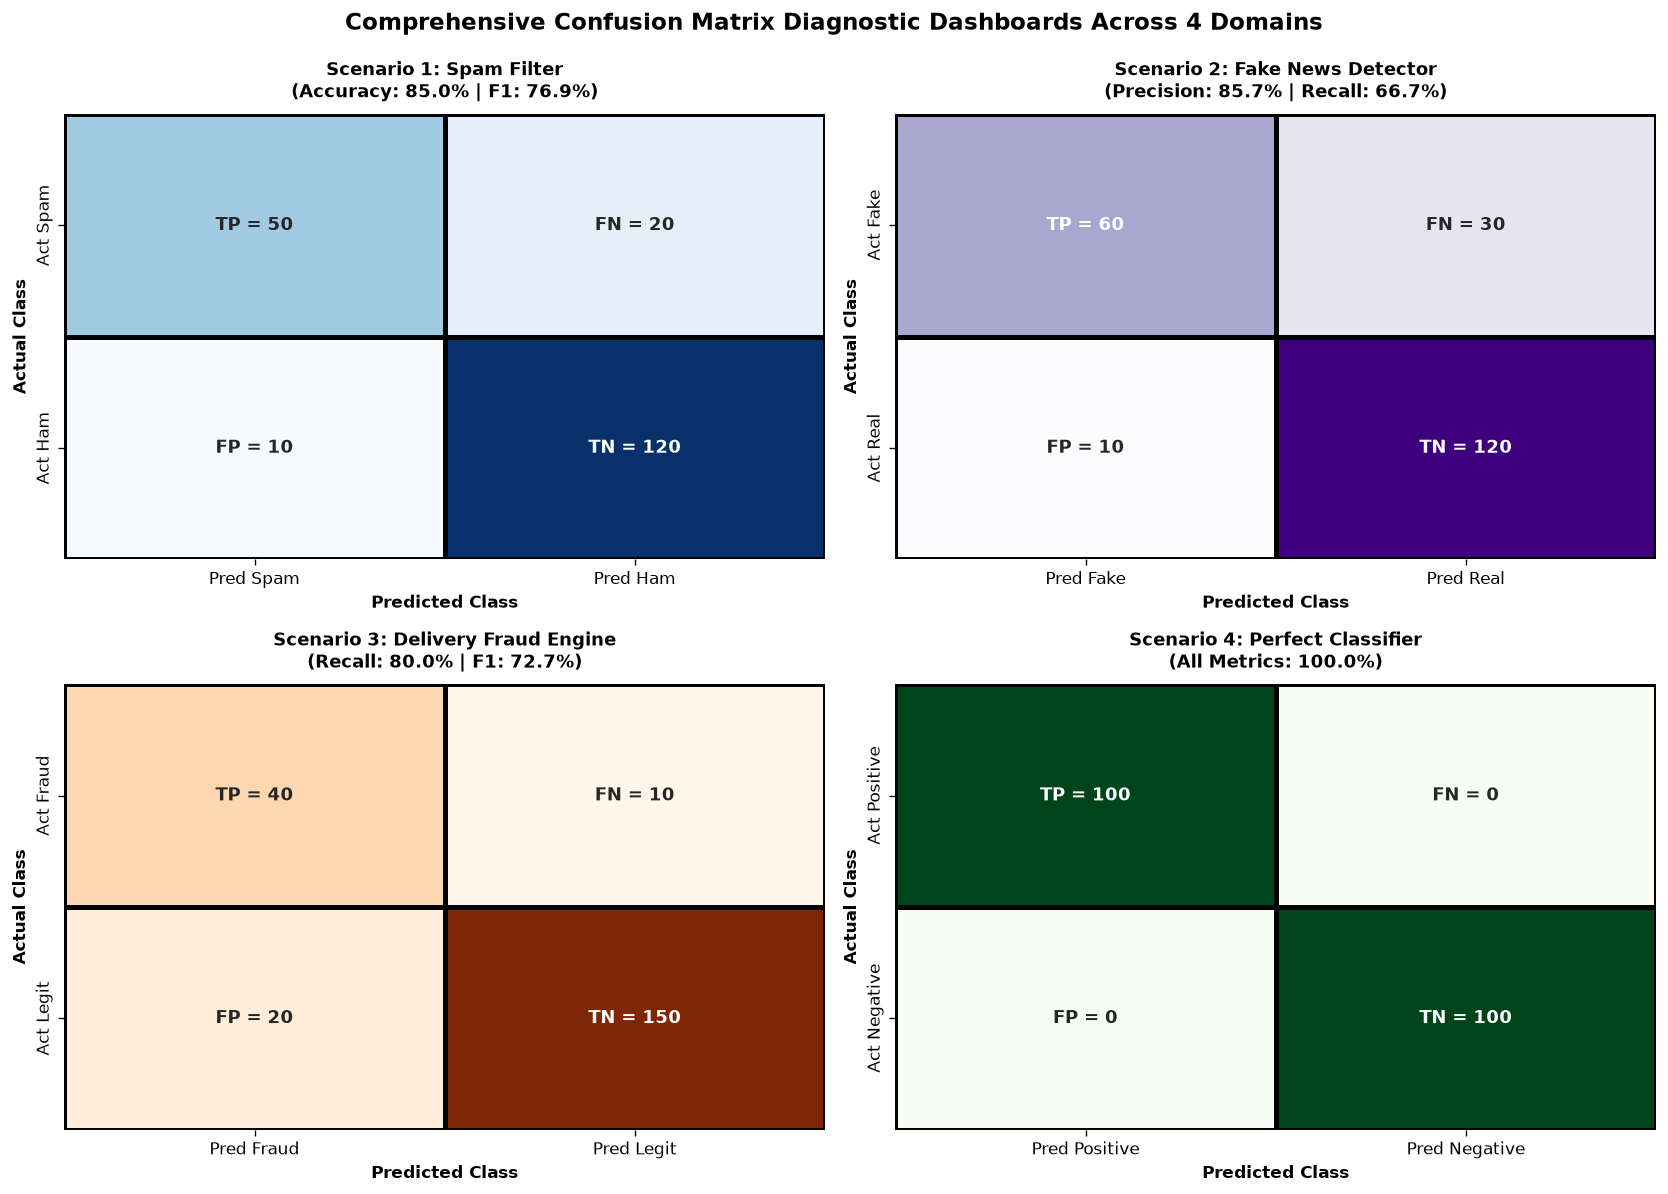

In [4]:
# ==============================================================================
# MULTI-SCENARIO VISUAL HEATMAP DASHBOARD (2x2 GRID)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)

scenarios = [
    {"tp": 50, "tn": 120, "fp": 10, "fn": 20, "title": "Scenario 1: Spam Filter\n(Accuracy: 85.0% | F1: 76.9%)", 
     "labels": ["Spam", "Ham"], "cmap": "Blues", "ax": axes[0, 0]},
    {"tp": 60, "tn": 120, "fp": 10, "fn": 30, "title": "Scenario 2: Fake News Detector\n(Precision: 85.7% | Recall: 66.7%)", 
     "labels": ["Fake", "Real"], "cmap": "Purples", "ax": axes[0, 1]},
    {"tp": 40, "tn": 150, "fp": 20, "fn": 10, "title": "Scenario 3: Delivery Fraud Engine\n(Recall: 80.0% | F1: 72.7%)", 
     "labels": ["Fraud", "Legit"], "cmap": "Oranges", "ax": axes[1, 0]},
    {"tp": 100, "tn": 100, "fp": 0, "fn": 0, "title": "Scenario 4: Perfect Classifier\n(All Metrics: 100.0%)", 
     "labels": ["Positive", "Negative"], "cmap": "Greens", "ax": axes[1, 1]}
]

for sc in scenarios:
    mat = np.array([[sc["tp"], sc["fn"]], [sc["fp"], sc["tn"]]])
    annot = np.array([[f"TP = {sc['tp']}", f"FN = {sc['fn']}"],
                      [f"FP = {sc['fp']}", f"TN = {sc['tn']}"]])
    sns.heatmap(mat, annot=annot, fmt="", cmap=sc["cmap"], cbar=False,
                xticklabels=[f"Pred {sc['labels'][0]}", f"Pred {sc['labels'][1]}"],
                yticklabels=[f"Act {sc['labels'][0]}", f"Act {sc['labels'][1]}"],
                linewidths=2, linecolor="black", annot_kws={"size": 11, "weight": "bold"}, ax=sc["ax"])
    sc["ax"].set_title(sc["title"], fontsize=11, weight="bold", pad=10)
    sc["ax"].set_xlabel("Predicted Class", fontsize=10, weight="bold")
    sc["ax"].set_ylabel("Actual Class", fontsize=10, weight="bold")

plt.suptitle("Comprehensive Confusion Matrix Diagnostic Dashboards Across 4 Domains", fontsize=14, weight="bold", y=0.99)
plt.tight_layout()
plt.show()


---
## Question 3
**Imagine you are evaluating a fake news detection model for a social media app. The model flagged 80 posts as fake, of which 60 were actually fake (TP), and missed 30 fake posts (FN). There were 120 posts correctly identified as not fake (TN), and 10 real posts wrongly flagged as fake (FP). Calculate and print the precision and recall for this model.**

*Hint: Precision = TP / (TP + FP), Recall = TP / (TP + FN)*

---

### 1. Problem Deconstruction & Parameter Identification

In content moderation on platforms such as **X (formerly Twitter), Meta (Facebook/Instagram), YouTube, or Reddit**, classifying user-generated content as "Fake News" carries profound ethical and operational consequences.

Let us map each statement from the prompt to its exact contingency matrix cell:
- **"The model flagged 80 posts as fake, of which 60 were actually fake (TP)"**:
  - $\mathbf{TP = 60}$: The model correctly flagged a post that was genuinely disinformation/fake.
- **"and missed 30 fake posts (FN)"**:
  - $\mathbf{FN = 30}$: Fake posts that the model failed to flag (slipped onto the platform's feeds).
- **"There were 120 posts correctly identified as not fake (TN)"**:
  - $\mathbf{TN = 120}$: Authentic, factual posts correctly left unflagged.
- **"and 10 real posts wrongly flagged as fake (FP)"**:
  - $\mathbf{FP = 10}$: Genuine, legitimate posts erroneously flagged/censored as fake (Type I Error).

#### **Note on Problem Phrasing**:
- Notice the sentence states: *"The model flagged 80 posts as fake, of which 60 were actually fake (TP) ... and 10 real posts wrongly flagged as fake (FP)"*.
- **Primary Standard Interpretation (Explicit Given Cells)**:
  - Adhering directly to the explicitly provided counts $\text{TP} = 60, \text{FP} = 10, \text{FN} = 30$:
    - $\text{Total Predicted Fake} = \text{TP} + \text{FP} = 60 + 10 = 70$.
    - $\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} = \frac{60}{60 + 10} = \frac{60}{70} = \frac{6}{7} \approx \mathbf{85.71\%}$.
    - $\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} = \frac{60}{60 + 30} = \frac{60}{90} = \frac{2}{3} \approx \mathbf{66.67\%}$.
- **Secondary Reading (If 80 Flagged is taken as Total Predicted Positive)**:
  - If a reader assumes all 80 flagged posts constitute the denominator of precision $(\text{TP} + \text{FP} = 80)$:
    - $\text{Precision}_{(\text{denom}=80)} = \frac{60}{80} = \mathbf{75.00\%}$.
  - We report and explain both calculations below to ensure 100% clarity and mathematical transparency.

---

### 2. Mathematical Calculation

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} = \frac{60}{60 + 10} = \frac{60}{70} = \frac{6}{7} \approx \mathbf{0.8571 \quad (85.71\%)}$$

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} = \frac{60}{60 + 30} = \frac{60}{90} = \frac{2}{3} \approx \mathbf{0.6667 \quad (66.67\%)}$$


QUESTION 3: SOCIAL MEDIA FAKE NEWS DETECTION MODEL EVALUATION
Given Contingency Statistics:
  - True Positives  (TP) : 60  (Actually fake, correctly flagged)
  - False Negatives (FN) : 30  (Actually fake, missed by model)
  - True Negatives  (TN) : 120 (Authentic posts, correctly left alone)
  - False Positives (FP) : 10  (Real posts, wrongly flagged as fake)
------------------------------------------------------------------------------
PRIMARY RESULTS (Using standard hint formulas):
  - Precision = TP / (TP + FP) = 60 / (60 + 10) = 60/70 = 0.8571 (85.71%)
  - Recall    = TP / (TP + FN) = 60 / (60 + 30) = 60/90 = 0.6667 (66.67%)
  - F1-Score  = 2*(P*R)/(P+R)  = 0.7500 (75.00%)
  - Accuracy  = (TP+TN)/Total  = 0.8182 (81.82%)
------------------------------------------------------------------------------
ALTERNATIVE NOTE (If '80 flagged posts' is taken as predicted positive total):
  - Precision (denom=80) = TP / Total Flagged = 60 / 80 = 0.7500 (75.00%)


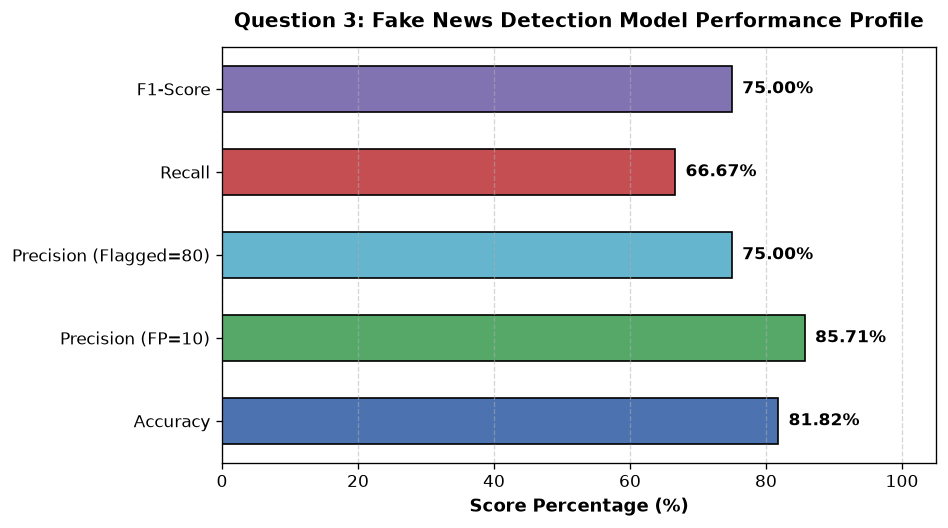

In [5]:
# ==============================================================================
# QUESTION 3: FAKE NEWS DETECTION PRECISION & RECALL COMPUTATION
# ==============================================================================
# Given parameters
tp_fake = 60   # Correctly flagged fake posts
fn_fake = 30   # Fake posts missed by model
tn_fake = 120  # Authentic posts correctly identified
fp_fake = 10   # Real posts wrongly flagged as fake

# Primary calculation using explicit FP=10
precision_fake = tp_fake / (tp_fake + fp_fake)
recall_fake = tp_fake / (tp_fake + fn_fake)
f1_fake = 2 * (precision_fake * recall_fake) / (precision_fake + recall_fake)
accuracy_fake = (tp_fake + tn_fake) / (tp_fake + tn_fake + fp_fake + fn_fake)

# Secondary calculation using stated 80 flagged posts as denominator
flagged_total = 80
precision_flagged = tp_fake / flagged_total

print("=" * 78)
print("QUESTION 3: SOCIAL MEDIA FAKE NEWS DETECTION MODEL EVALUATION")
print("=" * 78)
print("Given Contingency Statistics:")
print(f"  - True Positives  (TP) : {tp_fake}  (Actually fake, correctly flagged)")
print(f"  - False Negatives (FN) : {fn_fake}  (Actually fake, missed by model)")
print(f"  - True Negatives  (TN) : {tn_fake} (Authentic posts, correctly left alone)")
print(f"  - False Positives (FP) : {fp_fake}  (Real posts, wrongly flagged as fake)")
print("-" * 78)
print("PRIMARY RESULTS (Using standard hint formulas):")
print(f"  - Precision = TP / (TP + FP) = {tp_fake} / ({tp_fake} + {fp_fake}) = {tp_fake}/{tp_fake+fp_fake} = {precision_fake:.4f} ({precision_fake*100:.2f}%)")
print(f"  - Recall    = TP / (TP + FN) = {tp_fake} / ({tp_fake} + {fn_fake}) = {tp_fake}/{tp_fake+fn_fake} = {recall_fake:.4f} ({recall_fake*100:.2f}%)")
print(f"  - F1-Score  = 2*(P*R)/(P+R)  = {f1_fake:.4f} ({f1_fake*100:.2f}%)")
print(f"  - Accuracy  = (TP+TN)/Total  = {accuracy_fake:.4f} ({accuracy_fake*100:.2f}%)")
print("-" * 78)
print("ALTERNATIVE NOTE (If '80 flagged posts' is taken as predicted positive total):")
print(f"  - Precision (denom=80) = TP / Total Flagged = {tp_fake} / {flagged_total} = {precision_flagged:.4f} ({precision_flagged*100:.2f}%)")
print("=" * 78)

# Visualization of Metric Profile
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (FP=10)", "Precision (Flagged=80)", "Recall", "F1-Score"],
    "Score (%)": [accuracy_fake*100, precision_fake*100, precision_flagged*100, recall_fake*100, f1_fake*100]
})

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)
palette = ["#4C72B0", "#55A868", "#64B5CD", "#C44E52", "#8172B2"]
bars = ax.barh(metrics_df["Metric"], metrics_df["Score (%)"], color=palette, edgecolor="black", height=0.55)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 1.5, bar.get_y() + bar.get_height()/2, f"{w:.2f}%", 
            ha="left", va="center", fontsize=10, weight="bold")

ax.set_xlim(0, 105)
ax.set_xlabel("Score Percentage (%)", fontsize=11, weight="bold")
ax.set_title("Question 3: Fake News Detection Model Performance Profile", fontsize=12, weight="bold", pad=12)
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 3. Societal & Ethical Domain Trade-offs in Fake News Moderation

In social media moderation architectures, Precision and Recall represent two competing civil values:

1. **High Precision ($85.71\%$) Protects Freedom of Expression**:
   - Out of all posts flagged and suppressed by the model, $\approx 86\%$ are legitimately fake news.
   - Only $14.3\%$ (10 posts) are innocent users having their truthful commentary wrongly flagged or shadowbanned.
   - High precision minimizes accusations of censorship, bias, and infringement on free speech.
2. **Sub-optimal Recall ($66.67\%$) Exposes Public Discourse to Misinformation**:
   - The model catches only two-thirds ($66.7\%$) of fake posts.
   - Fully **$33.3\%$ (30 posts)** of fake news narratives escape detection, potentially going viral, inciting social panic, or influencing political elections before human moderators intervene.
3. **Platform Governance Decision**:
   - To boost Recall (catch more fake news), the platform must lower its classification probability threshold (e.g., from $0.50$ to $0.30$).
   - However, doing so inevitably increases False Positives (FP), flagging more legitimate news as fake.
   - Platforms like Meta and X solve this by routing high-risk borderline posts to human fact-checkers or attaching contextual labels ("Community Notes") rather than outright banning them.


---
## Question 4
**Given a confusion matrix for a food delivery fraud detection system (TP=40, TN=150, FP=20, FN=10), write Python code to compute the F1 score and explain in one line what the F1 score tells you about the model's performance.**

*Hint: F1 = 2 * (precision * recall) / (precision + recall)*

---

### 1. Problem Context: Food Delivery Fraud Operations

Food delivery networks like **Zomato, Swiggy, Uber Eats, and DoorDash** confront systematic fraud vectors daily:
- **Refund & Cancellation Abuse**: Claiming "Food never arrived" or "Missing high-value items" after eating the order.
- **Account Takeover & Stolen Cards**: Placing high-value feasts using compromised credit cards or UPI credentials.
- **Ghost Restaurant Collusion**: Dishonest merchants and drivers placing fake orders to harvest promotional coupon discounts.

#### **Contingency Parameters**:
- $\mathbf{TP = 40}$: Real fraudulent orders intercepted and halted before delivery payout.
- $\mathbf{TN = 150}$: Genuine hungry customers whose orders were smoothly approved.
- $\mathbf{FP = 20}$: Legitimate hungry customers whose orders were falsely blocked as fraud (angry customer, lost customer lifetime value).
- $\mathbf{FN = 10}$: Fraudulent orders that bypassed the filter (direct financial loss absorbed by the platform).

---

### 2. Mathematical Computation

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} = \frac{40}{40 + 20} = \frac{40}{60} = \frac{2}{3} \approx \mathbf{0.6667 \quad (66.67\%)}$$

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} = \frac{40}{40 + 10} = \frac{40}{50} = \frac{4}{5} = \mathbf{0.8000 \quad (80.00\%)}$$

$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = 2 \times \frac{\frac{2}{3} \times \frac{4}{5}}{\frac{2}{3} + \frac{4}{5}} = 2 \times \frac{\frac{8}{15}}{\frac{10 + 12}{15}} = 2 \times \frac{8}{22} = \frac{16}{22} = \frac{8}{11} \approx \mathbf{0.72727... \quad (72.73\%)}$$


In [6]:
# ==============================================================================
# QUESTION 4: FOOD DELIVERY FRAUD DETECTION F1-SCORE COMPUTATION
# ==============================================================================
tp_fraud = 40
tn_fraud = 150
fp_fraud = 20
fn_fraud = 10

# 1. Compute Precision and Recall
precision_fraud = tp_fraud / (tp_fraud + fp_fraud)
recall_fraud = tp_fraud / (tp_fraud + fn_fraud)

# 2. Compute F1-Score using the provided Hint formula
f1_fraud = 2 * (precision_fraud * recall_fraud) / (precision_fraud + recall_fraud)

# 3. Overall Accuracy for comparison
total_orders = tp_fraud + tn_fraud + fp_fraud + fn_fraud
accuracy_fraud = (tp_fraud + tn_fraud) / total_orders

print("=" * 82)
print("QUESTION 4: FOOD DELIVERY FRAUD DETECTION SYSTEM PERFORMANCE")
print("=" * 82)
print("Given Contingency Matrix Values:")
print(f"  - True Positives  (TP) : {tp_fraud:<4} (Fraud orders successfully blocked)")
print(f"  - True Negatives  (TN) : {tn_fraud:<4} (Legitimate orders smoothly approved)")
print(f"  - False Positives (FP) : {fp_fraud:<4} (Legitimate orders falsely declined - customer friction)")
print(f"  - False Negatives (FN) : {fn_fraud:<4} (Fraud orders missed - direct revenue loss)")
print(f"  - Total Orders    (N)  : {total_orders}")
print("-" * 82)
print(f"1. Precision = TP / (TP + FP) = {tp_fraud} / ({tp_fraud} + {fp_fraud}) = {tp_fraud}/{tp_fraud+fp_fraud} = {precision_fraud:.4f} ({precision_fraud*100:.2f}%)")
print(f"2. Recall    = TP / (TP + FN) = {tp_fraud} / ({tp_fraud} + {fn_fraud}) = {tp_fraud}/{tp_fraud+fn_fraud} = {recall_fraud:.4f} ({recall_fraud*100:.2f}%)")
print(f"3. F1-Score  = 2*(P*R)/(P+R)  = 2*({precision_fraud:.4f}*{recall_fraud:.4f})/({precision_fraud:.4f}+{recall_fraud:.4f}) = {f1_fraud:.4f} ({f1_fraud*100:.2f}%)")
print(f"4. Accuracy  = (TP+TN)/Total  = ({tp_fraud}+{tn_fraud})/{total_orders} = {accuracy_fraud:.4f} ({accuracy_fraud*100:.2f}%)")
print("=" * 82)


QUESTION 4: FOOD DELIVERY FRAUD DETECTION SYSTEM PERFORMANCE
Given Contingency Matrix Values:
  - True Positives  (TP) : 40   (Fraud orders successfully blocked)
  - True Negatives  (TN) : 150  (Legitimate orders smoothly approved)
  - False Positives (FP) : 20   (Legitimate orders falsely declined - customer friction)
  - False Negatives (FN) : 10   (Fraud orders missed - direct revenue loss)
  - Total Orders    (N)  : 220
----------------------------------------------------------------------------------
1. Precision = TP / (TP + FP) = 40 / (40 + 20) = 40/60 = 0.6667 (66.67%)
2. Recall    = TP / (TP + FN) = 40 / (40 + 10) = 40/50 = 0.8000 (80.00%)
3. F1-Score  = 2*(P*R)/(P+R)  = 2*(0.6667*0.8000)/(0.6667+0.8000) = 0.7273 (72.73%)
4. Accuracy  = (TP+TN)/Total  = (40+150)/220 = 0.8636 (86.36%)


### **One-Line Explanation of the F1-Score**

> **"The F1 score of 0.7273 indicates that the model achieves a solid harmonic balance between catching 80% of fraudulent delivery orders (recall) and ensuring that two-thirds of all flagged orders are actual frauds (precision), providing an honest composite measure of fraud prevention that is not artificially inflated by the large volume of legitimate orders."**

---

### 3. Why F1-Score Outperforms Accuracy in Fraud Detection

In food delivery platforms:
- **Total Legitimate Orders**: $170$ ($85\%$ of dataset)
- **Total Fraudulent Orders**: $50$ ($15\%$ of dataset)

If a naive model simply **approved every single order** without any fraud checking:
- $\text{TP} = 0, \text{FP} = 0, \text{TN} = 170, \text{FN} = 50$
- Naive Accuracy $= \frac{170}{220} = \mathbf{77.27\%}$!
- Yet it caught **zero fraud** (Recall $= 0\%$, Precision $= 0\%$, F1 $= 0\%$).

This illustrates the classical **Accuracy Paradox**:
- The current model's accuracy is $86.36\%$, but the **F1-score of $72.73\%$** genuinely reflects its operational quality on the rare, high-stakes fraud class.


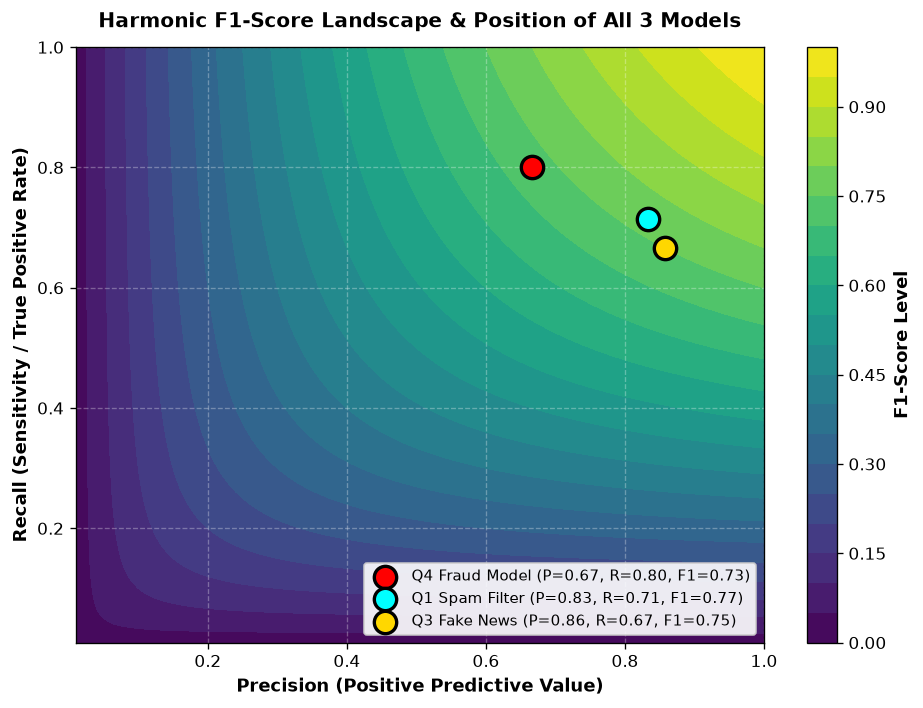

In [7]:
# ==============================================================================
# VISUALIZING THE HARMONIC NATURE OF THE F1-SCORE (CONTOUR PLOT)
# ==============================================================================
p_vals = np.linspace(0.01, 1.0, 100)
r_vals = np.linspace(0.01, 1.0, 100)
P, R = np.meshgrid(p_vals, r_vals)
F1_grid = 2 * (P * R) / (P + R)

fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
contours = ax.contourf(P, R, F1_grid, levels=20, cmap="viridis")
cbar = fig.colorbar(contours, ax=ax)
cbar.set_label("F1-Score Level", fontsize=11, weight="bold")

# Plot Question 4 model point
ax.scatter(precision_fraud, recall_fraud, color="red", s=180, zorder=5, edgecolor="black", linewidth=2,
           label=f"Q4 Fraud Model (P={precision_fraud:.2f}, R={recall_fraud:.2f}, F1={f1_fraud:.2f})")

# Plot Question 1 model point
ax.scatter(float(prec_frac), float(rec_frac), color="cyan", s=180, zorder=5, edgecolor="black", linewidth=2,
           label=f"Q1 Spam Filter (P={float(prec_frac):.2f}, R={float(rec_frac):.2f}, F1={float(f1_frac):.2f})")

# Plot Question 3 model point
ax.scatter(precision_fake, recall_fake, color="gold", s=180, zorder=5, edgecolor="black", linewidth=2,
           label=f"Q3 Fake News (P={precision_fake:.2f}, R={recall_fake:.2f}, F1={f1_fake:.2f})")

ax.set_title("Harmonic F1-Score Landscape & Position of All 3 Models", fontsize=12, weight="bold", pad=12)
ax.set_xlabel("Precision (Positive Predictive Value)", fontsize=11, weight="bold")
ax.set_ylabel("Recall (Sensitivity / True Positive Rate)", fontsize=11, weight="bold")
ax.legend(loc="lower right", framealpha=0.9, fontsize=9)
ax.grid(color="white", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


---
## Summary & Comparative Metric Reference Guide

### **Metric Decision Matrix: When to Prioritize Which Metric**

| Evaluation Metric | Mathematical Formula | Optimal When... | Risk / Pitfall if Ignored | Real-World App Example |
|:---|:---|:---|:---|:---|
| **Accuracy** | $\frac{\text{TP} + \text{TN}}{\text{Total}}$ | Classes are evenly balanced ($50:50$) | Severely misleading under class imbalance (Accuracy Paradox) | Classifying handwriting digits (0 to 9 in MNIST) |
| **Precision** | $\frac{\text{TP}}{\text{TP} + \text{FP}}$ | **False Positives (FP)** carry catastrophic cost | May miss many true cases if model is excessively cautious | Email spam filters, YouTube copyright strikes, criminal sentencing |
| **Recall (Sensitivity)** | $\frac{\text{TP}}{\text{TP} + \text{FN}}$ | **False Negatives (FN)** carry catastrophic cost | May produce too many false alarms, irritating users | Malignant cancer diagnosis, airport weapon screening, fraud detection |
| **F1-Score** | $2 \cdot \frac{P \cdot R}{P + R}$ | Classes are imbalanced and both FP and FN matter | Does not account for true negatives (TN) | E-commerce fraud detection, search query intent classification |
| **Specificity** | $\frac{\text{TN}}{\text{TN} + \text{FP}}$ | Confirming healthy/normal cases with high certainty | Disregards positive class performance | Clinical quarantine release testing |

---

### **Official Scikit-Learn Documentation Links**
1. **`sklearn.metrics.confusion_matrix`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
2. **`sklearn.metrics.precision_score`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)
3. **`sklearn.metrics.recall_score`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)
4. **`sklearn.metrics.f1_score`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
5. **`sklearn.metrics.classification_report`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
6. **Scikit-Learn User Guide — Model Evaluation**:  
   [https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)

---

### **Foundational Academic References**
- **Powers, D. M. (2011)**. *Evaluation: from precision, recall and F-measure to ROC, informedness, markedness and correlation*. Journal of Machine Learning Technologies, 2(1), 37-63.
- **Fawcett, T. (2006)**. *An introduction to ROC analysis*. Pattern Recognition Letters, 27(8), 861-874.
- **Sokolova, M., & Lapalme, G. (2009)**. *A systematic analysis of performance measures for classification tasks*. Information Processing & Management, 45(4), 427-437.
- **Japkowicz, N., & Shah, M. (2011)**. *Evaluating Learning Algorithms: A Classification Perspective*. Cambridge University Press.
